In [1]:
import os
import sys
import joblib
import numpy as np
import matplotlib.pyplot as plt
from rsatoolbox.inference import eval_fixed

sys.path.append('/home/reabt/experiments/ncc/MRI/code/')

from utils.load_cfg import load_MEG_config_instance
from utils.subj import *

In [2]:
oldSubjects = [f.split('_', 1)[0] for f in os.listdir('/home/reabt/experiments/ncc/bursts/data/data_4000')]
newSubjects = list(set(get_MEG_subjects()).difference(set(oldSubjects))) 

print(oldSubjects)
print(newSubjects)

Removed bad subject: 20050615buea

MEG subjects: ['20010917rswg', '20050204vrao', '19960630cahi', '19971028mrhs', '19970302urmr', '20000118sbnb', '20050610atbu', '19990810mrkh', '19800616mrgu', '20070324hlti', '19980223zlde', '19960531hibu', '19930306sbeh', '19840930bigs', '20040627vrrj', '19970520smsr', '20020705ttbr', '20000107ptfu', '19961123crsh', '19951227eipo', '19950623ajrn', '19921205crfi', '20040819knee', '19981005gndd', '20031022ekse', '19910823ssld', '19970605btre', '19960628gblm', '19970801cabd', '19920917gbse', '19942803fbjm', '19910703eigl', '20021027sldn']
['19950623ajrn', '19970520smsr', '19970605btre', '19980223zlde', '20000107ptfu', '20031022ekse', '19800616mrgu', '19920917gbse', '20040627vrrj', '20020705ttbr', '19971028mrhs', '19990810mrkh', '19981005gndd', '19960630cahi', '19910703eigl', '19970302urmr', '20040819knee', '19960628gblm', '19951227eipo', '19910823ssld', '19960531hibu']
['20050610atbu', '20021027sldn', '19921205crfi', '20010917rswg', '19840930bigs', '200

In [ ]:
def plot_mean_rsa_eval(config_class_name, all_subj, suffix = ''):

	cfg = load_MEG_config_instance(config_class_name) # uses '*' if no subjectID supplied
	models = cfg.get_model_RDM()

	if config_class_name == 'MEGconfig_C':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/C/'
		title_spec = 'Crossnobis'
	elif config_class_name == 'MEGconfig_E':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/E/'
		title_spec = 'Euclidean'
	elif config_class_name == 'MEGconfig_Eb':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/Eb/'
		title_spec = 'Euclidean'

	inFiles = os.listdir(inDir)
	print(f'first inFile: {inFiles[0]}')
	
	results_senso = []
	results_supra = []
	
	for file in inFiles:
		if "first" not in file:
			if os.path.splitext(file)[0][-12:] in all_subj: # only plot fusin subjects
				subj_data = joblib.load(os.path.join(inDir, file))
				eval_results = eval_fixed(models, subj_data, theta=None, method='corr_cov')

				results_senso.append(eval_results.evaluations[0,0])
				results_supra.append(eval_results.evaluations[0,1])

	# Convert lists of (200,) arrays → 2D arrays (n_subjects, n_timepoints)
	senso_arr = np.vstack(results_senso)   # shape (n_subj, 200)
	supra_arr = np.vstack(results_supra)

	# Compute mean and SEM (standard error of the mean) across subjects
	senso_mean = senso_arr.mean(axis=0)
	senso_sem  = senso_arr.std(axis=0, ddof=1) / np.sqrt(senso_arr.shape[0])

	supra_mean = supra_arr.mean(axis=0)
	supra_sem  = supra_arr.std(axis=0, ddof=1) / np.sqrt(supra_arr.shape[0])

	# X-axis (time points)
	time = np.arange(senso_arr.shape[1])

	# Plot with shaded error bars
	plt.figure(figsize=(10,5))

	plt.plot(time, senso_mean, label='Sensory', color='tab:blue')
	plt.fill_between(time, senso_mean - senso_sem, senso_mean + senso_sem, 
					 color='tab:blue', alpha=0.3)

	plt.plot(time, supra_mean, label='Suprasensory', color='tab:orange')
	plt.fill_between(time, supra_mean - supra_sem, supra_mean + supra_sem, 
					 color='tab:orange', alpha=0.3)

	plt.xlabel("Time points")
	plt.ylabel("Evaluation")
	plt.title(f"{title_spec}: Mean evaluations over time with SEM shaded {suffix}")
	plt.legend()
	plt.tight_layout()
	plt.show()

### Fusion subjects

Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']

fusion subjects: ['19951227eipo', '19970302urmr', '19910823ssld', '19910703eigl', '19960630cahi', '20010917rswg', '19921205crfi', '19840930bigs', '19961123crsh', '20040627vrrj', '19970520smsr', '20000118sbnb', '20070324hlti', '19960628gblm', '20050204vrao', '20050610atbu', '19930306sbeh', '20021027sldn', '19970801cabd']
first inFile: E_rdm_movie_19930306sbeh.pkl


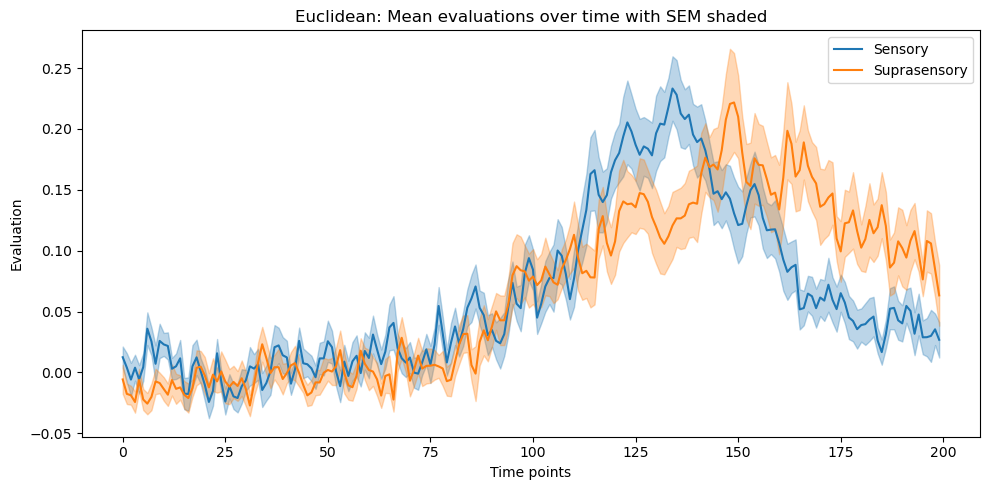

In [10]:
all_subj = get_fusion_subjects()
config_class_name = 'MEGconfig_E'
plot_mean_rsa_eval(config_class_name, all_subj)

Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']

fusion subjects: ['19951227eipo', '19970302urmr', '19910823ssld', '19910703eigl', '19960630cahi', '20010917rswg', '19921205crfi', '19840930bigs', '19961123crsh', '20040627vrrj', '19970520smsr', '20000118sbnb', '20070324hlti', '19960628gblm', '20050204vrao', '20050610atbu', '19930306sbeh', '20021027sldn', '19970801cabd']
first inFile: C_rdm_movie_cv_run_idx_19990810mrkh.pkl


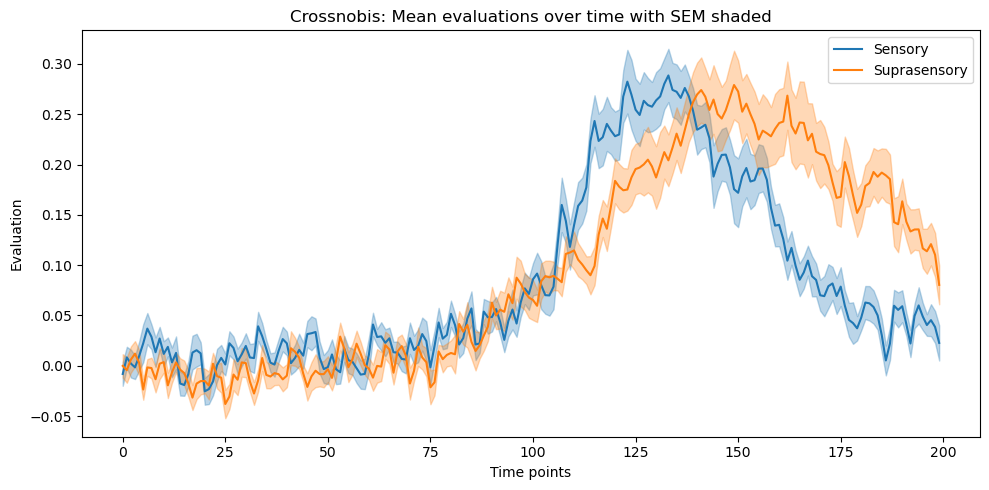

In [11]:
all_subj = get_fusion_subjects()
config_class_name = 'MEGconfig_C'
plot_mean_rsa_eval(config_class_name, all_subj)


MEG subjects: ['20010917rswg', '20050204vrao', '19960630cahi', '19971028mrhs', '19970302urmr', '20000118sbnb', '20050610atbu', '19990810mrkh', '19800616mrgu', '20070324hlti', '19980223zlde', '19960531hibu', '19930306sbeh', '19840930bigs', '20040627vrrj', '19970520smsr', '20000107ptfu', '19961123crsh', '19951227eipo', '19950623ajrn', '19921205crfi', '20040819knee', '19981005gndd', '20031022ekse', '19910823ssld', '19970605btre', '19960628gblm', '19970801cabd', '19920917gbse', '19942803fbjm', '19910703eigl', '20021027sldn']
Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']

fusion subjects: ['19951227eipo', '19970302urmr', '19910823ssld', '19910703eigl', '19960630cahi', '20010917rswg', '19921205crfi', '19840930bigs', '19961123crsh', '20040627vrrj', '19970520smsr', '20000118sbnb', '20070324hlti', '19960628gblm', '20050204vrao', '20050610atbu', '19930306sbeh',

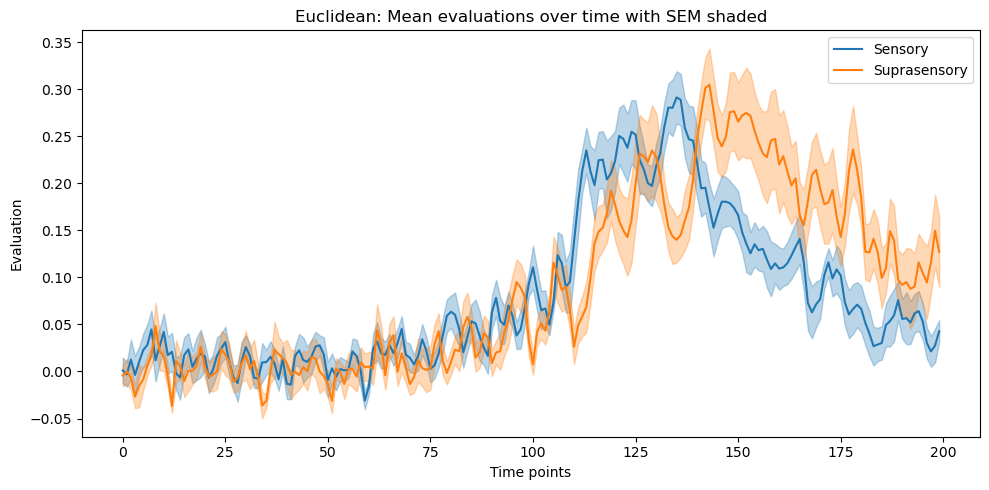

In [9]:
config_class_name = 'MEGconfig_E'
all_subj = list(set(get_MEG_subjects()).difference(set(get_fusion_subjects()))) 

plot_mean_rsa_eval(config_class_name, all_subj)

## old subjects only

first inFile: E_rdm_movie_19930306sbeh.pkl


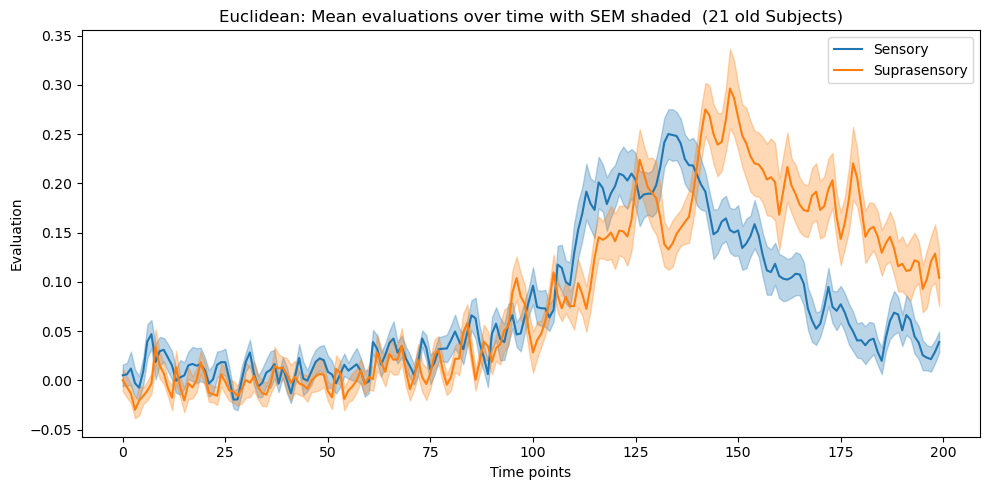

first inFile: E_rdm_movie_19930306sbeh.pkl


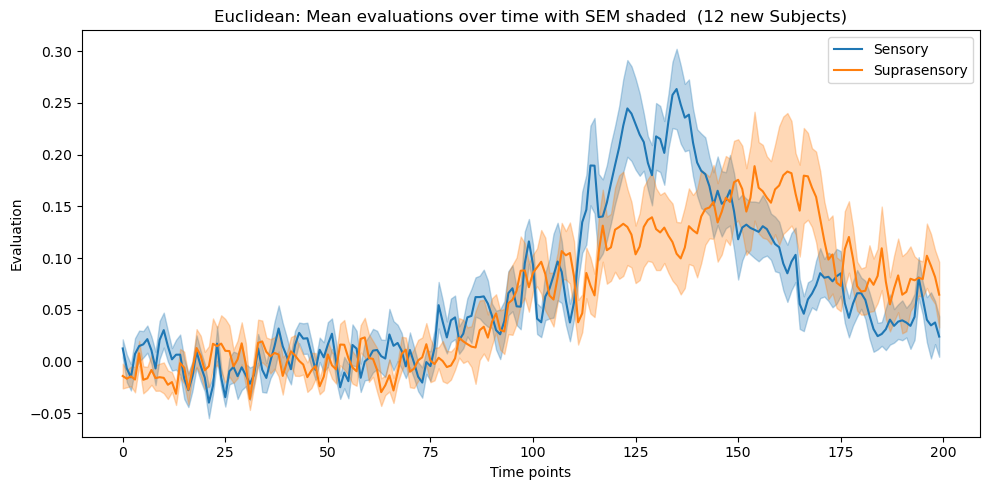

In [21]:
config_class_name = 'MEGconfig_E'
plot_mean_rsa_eval(config_class_name, oldSubjects, suffix = f' ({len(oldSubjects)} old Subjects)')
config_class_name = 'MEGconfig_E'
plot_mean_rsa_eval(config_class_name, newSubjects, suffix = f' ({len(newSubjects)} new Subjects)')

first inFile: C_rdm_movie_cv_run_idx_19990810mrkh.pkl


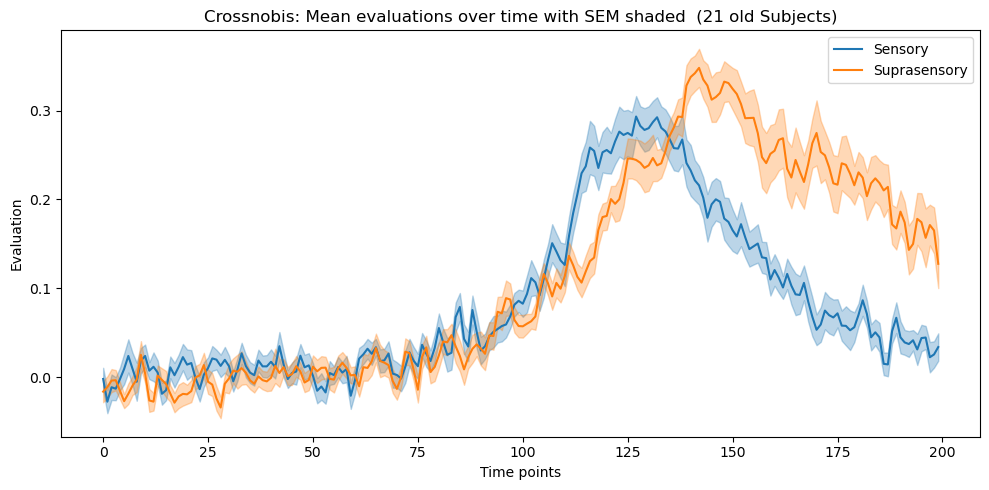

first inFile: C_rdm_movie_cv_run_idx_19990810mrkh.pkl


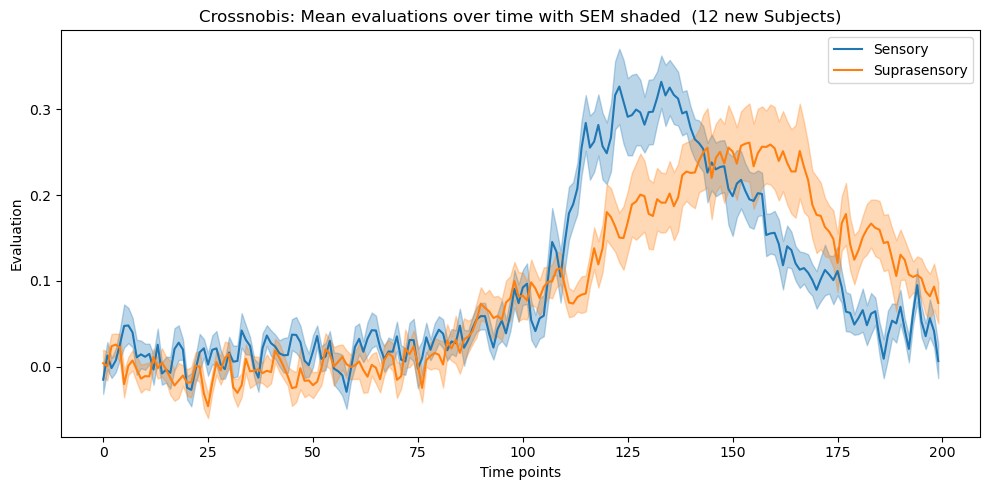

In [20]:
config_class_name = 'MEGconfig_C'
plot_mean_rsa_eval(config_class_name, oldSubjects, suffix = f' ({len(oldSubjects)} old Subjects)')
config_class_name = 'MEGconfig_C'
plot_mean_rsa_eval(config_class_name, newSubjects, suffix = f' ({len(newSubjects)} new Subjects)')

using new MEG prepro data

Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']

fusion subjects: ['19951227eipo', '19970302urmr', '19910823ssld', '20020705ttbr', '19910703eigl', '19960630cahi', '20010917rswg', '19921205crfi', '19840930bigs', '19961123crsh', '20040627vrrj', '19970520smsr', '20000118sbnb', '20070324hlti', '19960628gblm', '20050204vrao', '20050610atbu', '19930306sbeh', '20021027sldn', '19970801cabd']
first inFile: Eb_rdm_movie_19970605btre.pkl


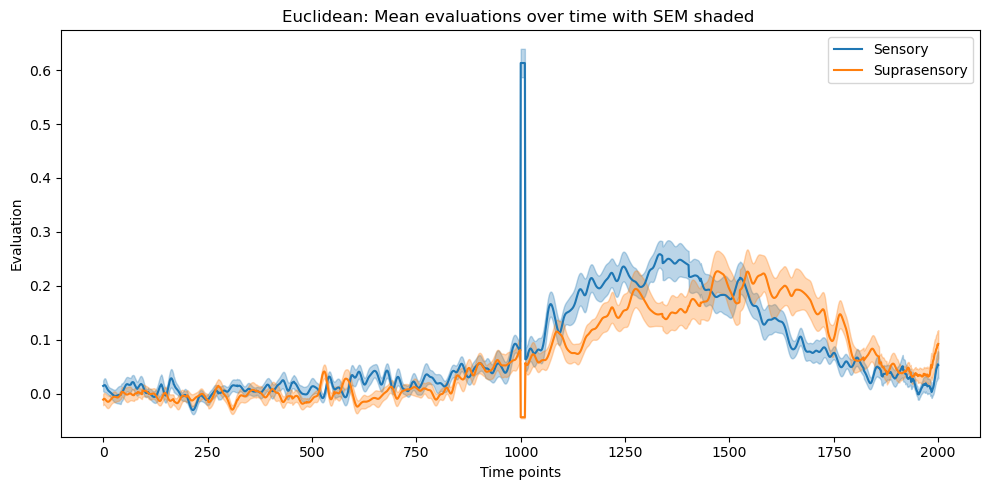

In [6]:
all_subj = get_fusion_subjects()
config_class_name = 'MEGconfig_Eb'
plot_mean_rsa_eval(config_class_name, all_subj)